In [28]:
import pandas as pd
import numpy as np
from IPython.display import display
import sys, os
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [29]:
df_train_raw = pd.read_csv('../data/raw/train.csv').drop('Id', axis=1)
df_train = df_train_raw.copy()
#df_train = df_train.drop('SalePrice', axis=1)  # labels deleted 
print(f'start dimensions --> {df_train_raw.shape}')
df_train_raw.head()

start dimensions --> (1460, 80)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [30]:
#Analisis de datos faltantes
missing_data = df_train_raw.isnull().sum()
missing_data = pd.DataFrame(missing_data[missing_data > 0], columns=['missing_count'])
missing_data['missing_percentage (%)'] = np.round(missing_data['missing_count'] / df_train_raw.shape[0] * 100, 2)
missing_data = missing_data.sort_values(by='missing_count', ascending=False)
print('fields with missing data:')
missing_data

fields with missing data:


,missing_count,missing_percentage (%)
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


In [31]:
#Manejo de datos faltantes
#Paso inicial eliminar las columnas que tienen mas del 85% de datos faltantes

#LotFrontage: La longitud lineal (en pies) de la calle que bordea la propiedad.
#Alley: El tipo de acceso al callejón.
#MasVnrType: El tipo de revestimiento de mampostería.
#FireplaceQu: La calidad de la chimenea.
#PoolQC: La calidad de la piscina.
#Fence: La calidad de la valla.
#MiscFeature: Una característica miscelánea no cubierta en otras categorías.

print(f'start dimentions {df_train.shape}')
initial_columns = df_train.columns
df_train = df_train.dropna(thresh=len(df_train) * 0.85, axis=1)
columns_deleted = [col for col in initial_columns if col not in df_train.columns]
print(f'columns deleted ({len(columns_deleted)}) --> {columns_deleted}')

start dimentions (1460, 80)
columns deleted (7) --> ['LotFrontage', 'Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']


In [32]:
#Columnas con datos faltantes resultantes de la eliminacion anterior
#Definir en una funcion
def missing_data_report(df):
    missing_res_deleted = df.isnull().sum()
    missing_res_deleted = missing_res_deleted[missing_res_deleted > 0].sort_values(ascending=True)
    return missing_res_deleted
res = missing_data_report(df_train)
res

Electrical       1
MasVnrArea       8
BsmtCond        37
BsmtQual        37
BsmtFinType1    37
BsmtExposure    38
BsmtFinType2    38
GarageType      81
GarageYrBlt     81
GarageFinish    81
GarageQual      81
GarageCond      81
dtype: int64

In [33]:
#imputacion simple
#Electrical: El sistema eléctrico. -> Valores faltantes imputados con la moda
df_train['Electrical'] = df_train['Electrical'].fillna(df_train['Electrical'].mode()[0])
#MasVnrArea: Área de revestimiento de mampostería en pies cuadrados. -> Valores faltantes imputados con (0)
df_train['MasVnrArea'] = df_train['MasVnrArea'].fillna(0)

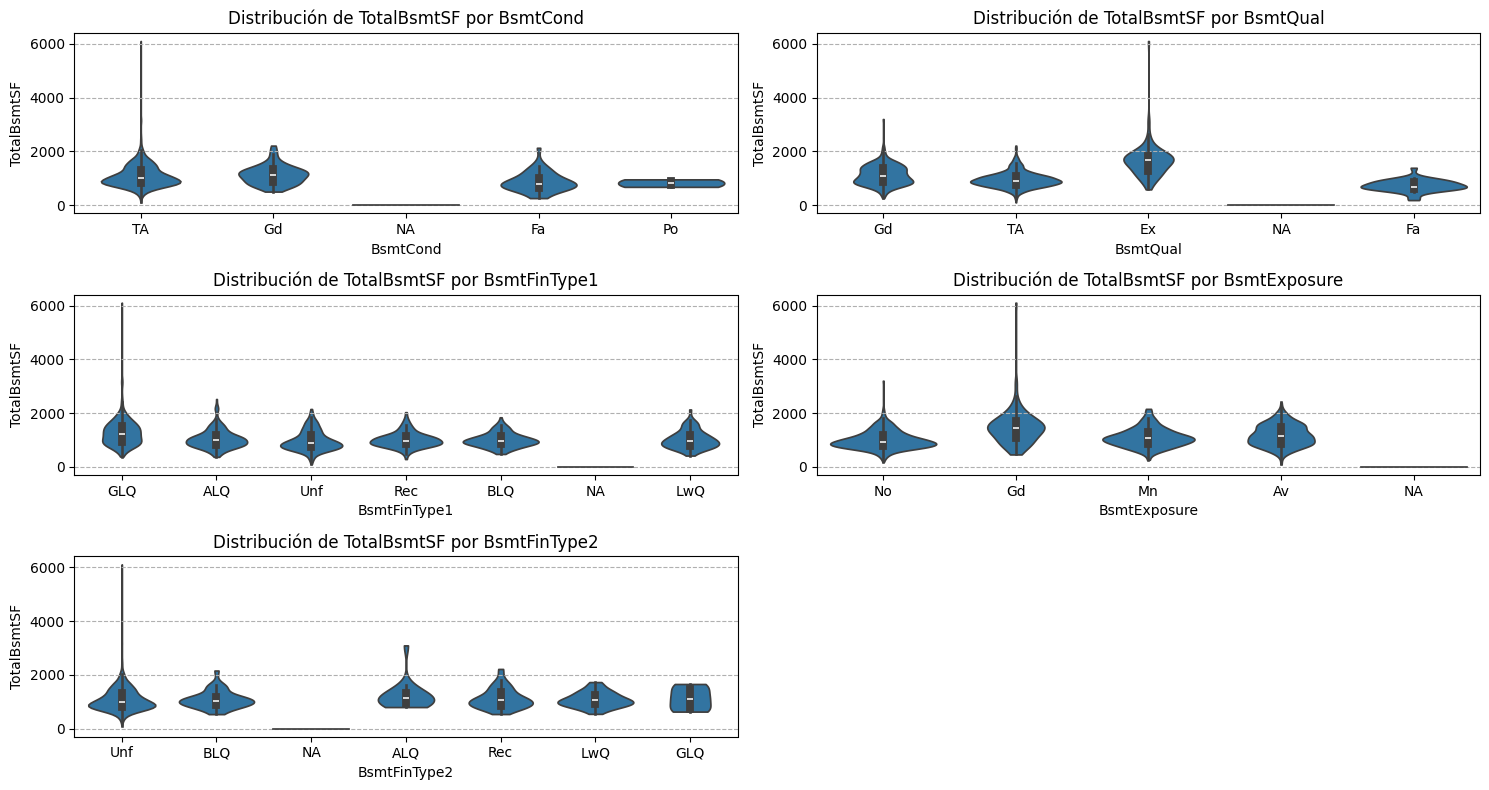

In [34]:
cond_not_basement = (df_train['TotalBsmtSF'] == 0) & (df_train['BsmtUnfSF'] == 0)
#BsmtCond: Evalúa la condición general del sótano. -> (NA) no tiene sótano
#BsmtQual: Evalúa la altura del sótano. -> (NA) no tiene sótano
##BsmtFinType1: Evaluación del tipo de acabado del sótano. -> (NA) no tiene sótano
#BsmtExposure: Refleja la cantidad de exposición al sótano al aire exterior. -> (NA) no tiene sótano
#BsmtFinType2: Evaluación del tipo de acabado del sótano (si hay dos tipos). -> (NA) no tiene sótano
cols_not_basement = ['BsmtCond', 'BsmtQual', 'BsmtFinType1', 'BsmtExposure', 'BsmtFinType2']
df_train.loc[cond_not_basement, cols_not_basement] = df_train.loc[cond_not_basement, cols_not_basement].fillna('NA')
fig, ax = plt.subplots(ncols=2, nrows=3)
fig.set_size_inches(15,8)

axisOne = sns.violinplot(x='BsmtCond', y='TotalBsmtSF', data=df_train, cut=0, ax=ax[0][0])
axisOne.set_title('Distribución de TotalBsmtSF por BsmtCond')
axisOne.set_xlabel('BsmtCond')
axisOne.set_ylabel('TotalBsmtSF')
axisOne.grid(axis='y', linestyle='--');

axisTwo = sns.violinplot(x='BsmtQual', y='TotalBsmtSF', data=df_train, cut=0, ax=ax[0][1])
axisTwo.set_title('Distribución de TotalBsmtSF por BsmtQual')
axisTwo.set_xlabel('BsmtQual')
axisTwo.set_ylabel('TotalBsmtSF')
axisTwo.grid(axis='y', linestyle='--');

axisThree = sns.violinplot(x='BsmtFinType1', y='TotalBsmtSF', data=df_train, cut=0, ax=ax[1][0])
axisThree.set_title('Distribución de TotalBsmtSF por BsmtFinType1')
axisThree.set_xlabel('BsmtFinType1')
axisThree.set_ylabel('TotalBsmtSF')
axisThree.grid(axis='y', linestyle='--');

axisFour = sns.violinplot(x='BsmtExposure', y='TotalBsmtSF', data=df_train, cut=0, ax=ax[1][1])
axisFour.set_title('Distribución de TotalBsmtSF por BsmtExposure')
axisFour.set_xlabel('BsmtExposure')
axisFour.set_ylabel('TotalBsmtSF')
axisFour.grid(axis='y', linestyle='--');
axisFive = sns.violinplot(x='BsmtFinType2', y='TotalBsmtSF', data=df_train, cut=0, ax=ax[2][0])
axisFive.set_title('Distribución de TotalBsmtSF por BsmtFinType2')
axisFive.set_xlabel('BsmtFinType2')
axisFive.set_ylabel('TotalBsmtSF')
axisFive.grid(axis='y', linestyle='--');
fig.delaxes(ax[2][1])
plt.tight_layout()

In [35]:
#Columnas con datos faltantes resultantes de la eliminacion anterior

#TotalBsmtSF: Pies cuadrados totales del sótano.
#BsmtUnfSF: Pies cuadrados del sótano sin terminar.
#BsmtCond: Evalúa la condición general del sótano
#BsmtFinType1: Evaluación del tipo de acabado del sótano.
#BsmtFinSF1: Pies cuadrados del tipo de acabado 1 del sótano.
#BsmtFinType2: Evaluación del tipo de acabado del sótano (si hay dos tipos). (x)
#BsmtFinSF2: Pies cuadrados del tipo de acabado 2 del sótano.

#BsmtQual: Evalúa la altura del sótano.
#BsmtExposure: Refleja la cantidad de exposición al sótano al aire exterior. (x)
#BsmtFullBath: Número de baños completos en el sótano.
#BsmtHalfBath: Número de medios baños en el sótano.

df_train['BsmtExposure'] = df_train['BsmtExposure'].fillna(df_train.groupby(['BsmtCond', 'BsmtFinType1', 'BsmtFinType2', 'BsmtQual', 'BsmtFullBath', 'BsmtHalfBath'])['BsmtExposure']
                                                    .transform(lambda x: x.mode()[0] if not x.mode().empty else 'No'))
df_train['BsmtFinType2'] = df_train['BsmtFinType2'].fillna(df_train.groupby(['BsmtCond', 'BsmtQual', 'BsmtFullBath', 'BsmtHalfBath', 'BsmtExposure'])['BsmtFinType2']
                                                    .transform(lambda x: x.mode()[0] if not x.mode().empty else 'Unf'))

In [36]:
#Imputacion de datos faltantes en columnas relacionadas con el garage ['GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond'] -> ['GarageArea', 'GarageCars']
#GarageType ->  Ubicación del garaje. (NA) no tiene garage
#GarageYrBlt -> Año de construcción del garaje. (0) no tiene garage
#GarageFinish -> Acabado interior del garaje. (NA) no tiene garage
#GarageQual -> Calidad del garaje. (NA) no tiene garage
#GarageCond -> Condición del garaje. (NA) no tiene garage
list_categorical_not_garage = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']
list_numerical_not_garage = ['GarageYrBlt']
cond_not_garage = df_train['GarageArea'] == 0
df_train.loc[cond_not_garage, list_categorical_not_garage] = df_train.loc[cond_not_garage, list_categorical_not_garage].fillna('NA')
df_train.loc[cond_not_garage, list_numerical_not_garage] = df_train.loc[cond_not_garage, list_numerical_not_garage].fillna(0)

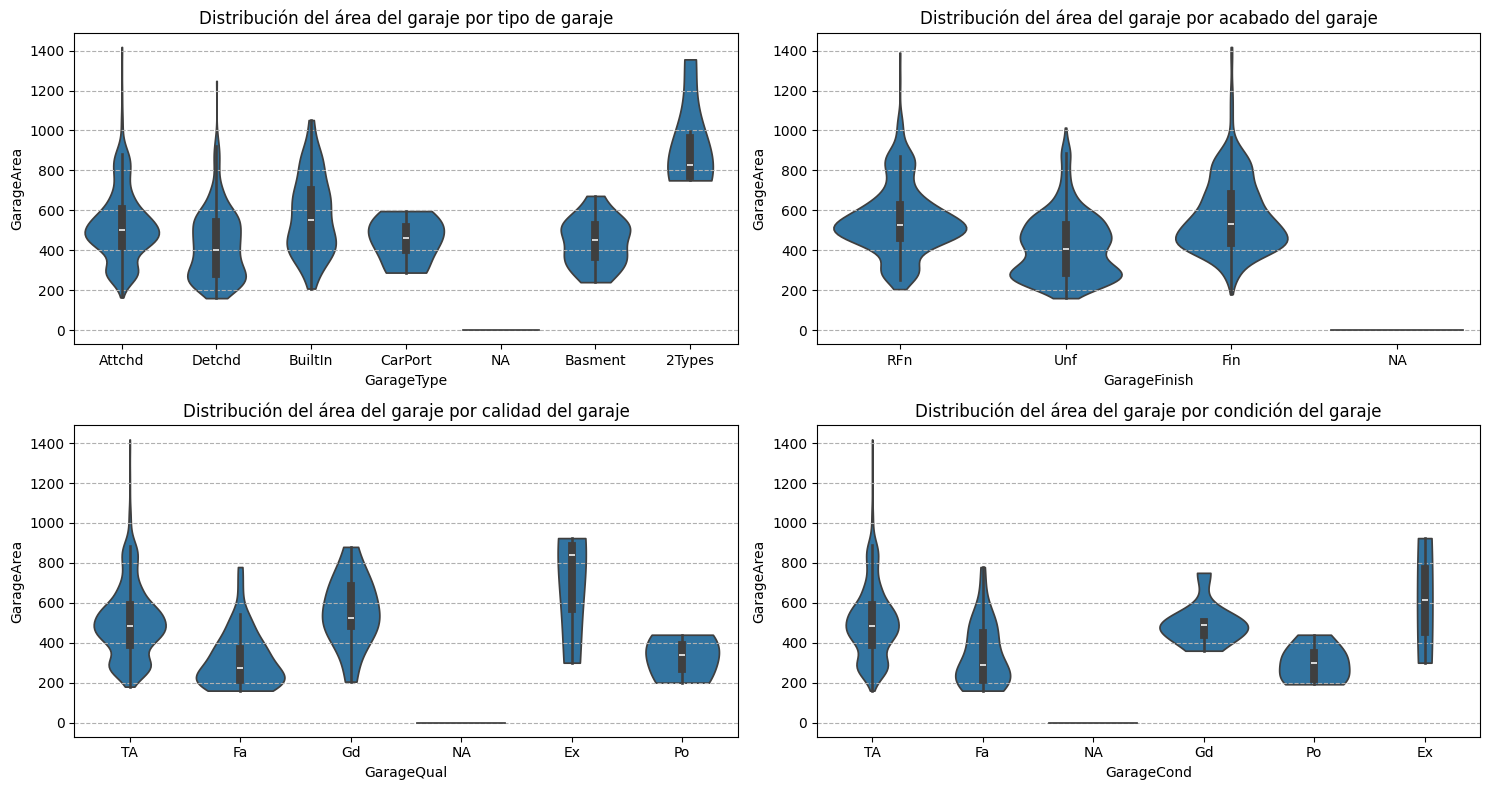

In [37]:
fig, ax = plt.subplots(ncols=2, nrows=2)
fig.set_size_inches(15,8)
axisType = sns.violinplot(x='GarageType', y='GarageArea', data=df_train, cut=0, ax=ax[0][0])
axisType.set_title('Distribución del área del garaje por tipo de garaje')
axisType.set_xlabel('GarageType')
axisType.set_ylabel('GarageArea')
axisType.grid(axis='y', linestyle='--');
axisFinish = sns.violinplot(x='GarageFinish', y='GarageArea', data=df_train, cut=0, ax=ax[0][1])
axisFinish.set_title('Distribución del área del garaje por acabado del garaje')
axisFinish.set_xlabel('GarageFinish')
axisFinish.set_ylabel('GarageArea')
axisFinish.grid(axis='y', linestyle='--');
axisQual = sns.violinplot(x='GarageQual', y='GarageArea', data=df_train, cut=0, ax=ax[1][0])
axisQual.set_title('Distribución del área del garaje por calidad del garaje')
axisQual.set_xlabel('GarageQual')
axisQual.set_ylabel('GarageArea')
axisQual.grid(axis='y', linestyle='--');
axisCond = sns.violinplot(x='GarageCond', y='GarageArea', data=df_train, cut=0, ax=ax[1][1])
axisCond.set_title('Distribución del área del garaje por condición del garaje')
axisCond.set_xlabel('GarageCond')
axisCond.set_ylabel('GarageArea')
axisCond.grid(axis='y', linestyle='--');
plt.tight_layout()


In [38]:
#Feature engineering
print(f'Numero de features --> {len(df_train.columns)}')
numeric_features = df_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df_train.select_dtypes(include=[object]).columns.tolist()
print(f'numericas {len(numeric_features)} --> {numeric_features}')
print(f'categoricas {len(categorical_features)} --> {categorical_features}')

Numero de features --> 73
numericas 36 --> ['MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']
categoricas 37 --> ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'GarageType', 'GarageFinish', 'G

------------------------------------------------------------
MSZoning: --> One-Hot-Encoding
🔴 missing categories ['RP', 'I', 'A']


,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM
0,0,0,0,1,0
1,0,0,0,1,0
2,0,0,0,1,0
3,0,0,0,1,0
4,0,0,0,1,0


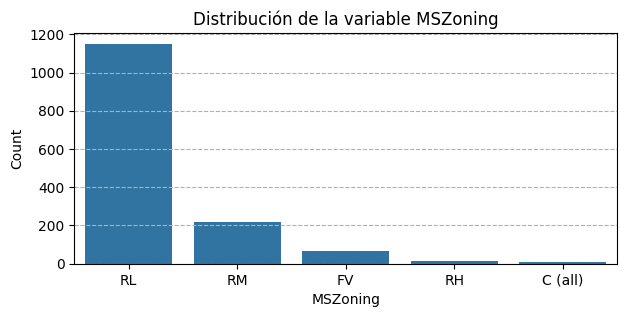

In [39]:
#MSZoning: Clasificación general de la zona de uso del suelo.
print('---'*20)
print('MSZoning: --> One-Hot-Encoding')
#Considerar valores categoricos de MSZoning que no tienen ejemplos en el set de entrenamiento
#No se tiene un orden definido en las categorias
#Pocas categorias
#Visto que las categorias no tienen un orden definido, se procede a hacer one-hot-encoding
mszoning_cat_all = ['A', 'C (all)', 'FV', 'I', 'RH', 'RL', 'RP', 'RM']
mszoning_cat_train = df_train['MSZoning'].unique().tolist()
missing_cats = list(set(mszoning_cat_all) - set(mszoning_cat_train))
print(f'{"🟢" if len(missing_cats) == 0 else "🔴"} missing categories {missing_cats}')
ohe_mszoning = pd.get_dummies(df_train['MSZoning'], prefix='MSZoning', dtype=int)
display(ohe_mszoning.head())

plt.figure(figsize=(7,3))
sns.countplot(data=df_train, x='MSZoning', order=df_train['MSZoning'].value_counts().index)
plt.title('Distribución de la variable MSZoning')
plt.xlabel('MSZoning')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--');

------------------------------------------------------------
Street: --> One-Hot-Encoding
🟢 missing categories []


,Street_Grvl,Street_Pave
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


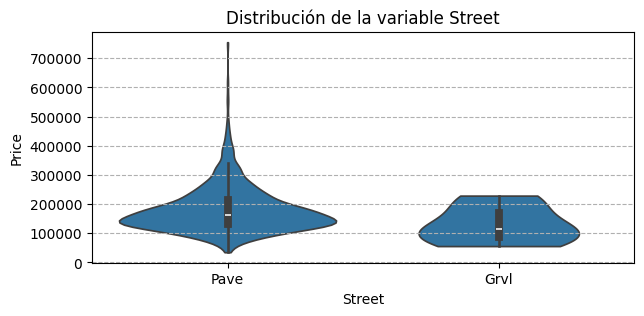

In [40]:
#Street: Tipo de acceso a la calle.
print('---'*20)
print('Street: --> One-Hot-Encoding')
street_cat_all = ['Grvl', 'Pave']
street_cat_train = df_train['Street'].unique().tolist()
missing_cats = list(set(street_cat_all) - set(street_cat_train))
print(f'{"🟢" if len(missing_cats) == 0 else "🔴"} missing categories {missing_cats}')
#No se tiene un orden definido en las categorias
#Pocas categorias
#Visto que las categorias no tienen un orden definido, se procede a hacer one-hot-encoding
ohe_street = pd.get_dummies(df_train['Street'], prefix='Street', dtype=int)
display(ohe_street.head())


plt.figure(figsize=(7,3))
sns.violinplot(x='Street', y='SalePrice', data=df_train, cut=0)
plt.title('Distribución de la variable Street')
plt.xlabel('Street')
plt.ylabel('Price')
plt.grid(axis='y', linestyle='--');


------------------------------------------------------------
LotShape: --> Ordinal Encoding
🟢 missing categories []


{'Reg': 0, 'IR1': 1, 'IR2': 2, 'IR3': 3}

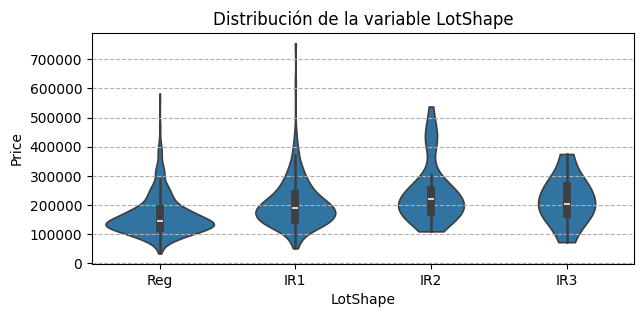

In [51]:
#LotShape: Forma de la parcela.
print('---'*20)
print('LotShape: --> Ordinal Encoding')
lotshape_cat_all = ['Reg', 'IR1', 'IR2', 'IR3']
lotshape_cat_train = df_train['LotShape'].unique().tolist()
missing_cats = list(set(lotshape_cat_all) - set(lotshape_cat_train))
print(f'{"🟢" if len(missing_cats) == 0 else "🔴"} missing categories {missing_cats}')
#Se tiene un orden definido en las categorias
#Pocas categorias
#Visto que las categorias tienen un orden definido, se procede a hacer ordinal-encoding
#Preliminarmene se hara un mapeo estandar
mapping_lotshape = {'Reg': 0, 'IR1': 1, 'IR2': 2, 'IR3': 3}
display(mapping_lotshape)

plt.figure(figsize=(7,3))
sns.violinplot(x='LotShape', y='SalePrice', data=df_train, order=lotshape_cat_all, cut=0)
plt.title('Distribución de la variable LotShape')
plt.xlabel('LotShape')
plt.ylabel('Price')
plt.grid(axis='y', linestyle='--');

------------------------------------------------------------
LandContour: --> Ordinal Encoding
🟢 missing categories []


LandContour
Bnk    143104.079365
Lvl    180183.746758
Low    203661.111111
HLS    231533.940000
Name: SalePrice, dtype: float64

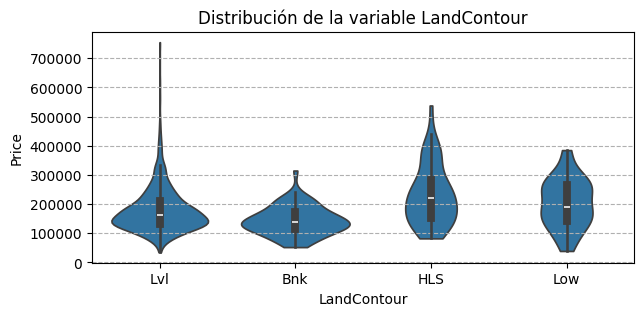

In [52]:
#LandContour: Plano de la parcela.
print('---'*20)
print('LandContour: --> Ordinal Encoding')
landcontour_cat_all = ['Lvl', 'Bnk', 'HLS', 'Low']
landcontour_cat_train = df_train['LandContour'].unique().tolist()
missing_cats = list(set(landcontour_cat_all) - set(landcontour_cat_train))
print(f'{"🟢" if len(missing_cats) == 0 else "🔴"} missing categories {missing_cats}')
#Se tiene un orden definido en las categorias
#Pocas categorias
#Visto que las categorias tienen un orden definido, se procede a hacer ordinal-encoding

mean_price = df_train.groupby('LandContour')['SalePrice'].mean().sort_values()
display(mean_price)

plt.figure(figsize=(7,3))
sns.violinplot(x='LandContour', y='SalePrice', data=df_train, order=landcontour_cat_all, cut=0)
plt.title('Distribución de la variable LandContour')
plt.xlabel('LandContour')
plt.ylabel('Price')
plt.grid(axis='y', linestyle='--');

mapping_landcontour = {'Lvl': 0, 'Bnk': 1, 'HLS': 2, 'Low': 3}

------------------------------------------------------------
Utilities: --> Ordinal Encoding
🔴 missing categories ['ELO', 'NoSewr']


Utilities
NoSeWa    137500.00000
AllPub    180950.95682
Name: SalePrice, dtype: float64

{'AllPub': 3, 'NoSewr': 2, 'NoSeWa': 1, 'ELO': 0}

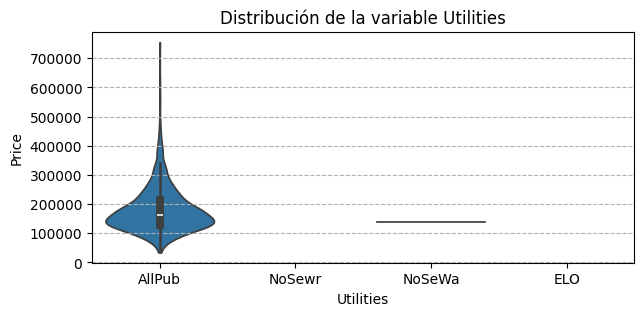

In [55]:
#Utilities: Tipo de servicios públicos disponibles.
print('---'*20)
print('Utilities: --> Ordinal Encoding')
utilities_cat_all = ['AllPub', 'NoSewr', 'NoSeWa', 'ELO']
utilities_cat_train = df_train['Utilities'].unique().tolist()
missing_cats = list(set(utilities_cat_all) - set(utilities_cat_train))
print(f'{"🟢" if len(missing_cats) == 0 else "🔴"} missing categories {missing_cats}')

mapping_utilities = {'AllPub': 3, 'NoSewr': 2, 'NoSeWa': 1, 'ELO': 0}

mean_price = df_train.groupby('Utilities')['SalePrice'].mean().sort_values()
display(mean_price)
#Se tiene un orden definido en las categorias
#Pocas categorias
#Visto que las categorias tienen un orden definido, se procede a hacer ordinal-encoding
#@@@: Puede ser probada con one-hot-encoding
display(mapping_utilities)
plt.figure(figsize=(7,3))
sns.violinplot(x='Utilities', y='SalePrice', data=df_train, order=utilities_cat_all, cut=0)
plt.title('Distribución de la variable Utilities')
plt.xlabel('Utilities')
plt.ylabel('Price')
plt.grid(axis='y', linestyle='--');